# Assignment 4: SHAP and EBM

In this work, an XGBoost model is built on the California Housing dataset. After that, SHAP values are used to analyze feature importance and feature interactions. Then a depth-1 boosting model is trained in order to construct interpretable shape functions for the most important features. Finally, additional visualizations are presented for pairs and triples of features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import partial_dependence

import xgboost as xgb
import shap
from mpl_toolkits.mplot3d import Axes3D

## Loading the dataset

The California Housing dataset is used for the regression task of predicting housing prices based on demographic and geographical features.

In [2]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)
print(X.columns.tolist())

(16512, 8) (4128, 8)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Hyperparameter tuning of the XGBoost model

To improve predictive performance, hyperparameter tuning is performed using RandomizedSearchCV. The best parameter combination is selected based on cross-validated RMSE.

In [3]:
base_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 2, 5]
}

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)

best_model = search.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters:
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


## Evaluation of the tuned model

After hyperparameter tuning, the predictive quality of the selected XGBoost model is evaluated on the test set using RMSE and R².

In [4]:
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Tuned model RMSE:", rmse)
print("Tuned model R2:", r2)

Tuned model RMSE: 0.4436106671269846
Tuned model R2: 0.8498251864444482


The tuned XGBoost model demonstrates strong predictive performance on the test set. The obtained RMSE is relatively low, while the R² score shows that the model explains a large proportion of the variance in housing prices. Therefore, the tuned model is used for the subsequent SHAP analysis.

## SHAP analysis of feature importance

SHAP values are computed in order to determine the contribution of each feature to the model prediction. The SHAP summary plot provides a global interpretation of feature importance and direction of influence.

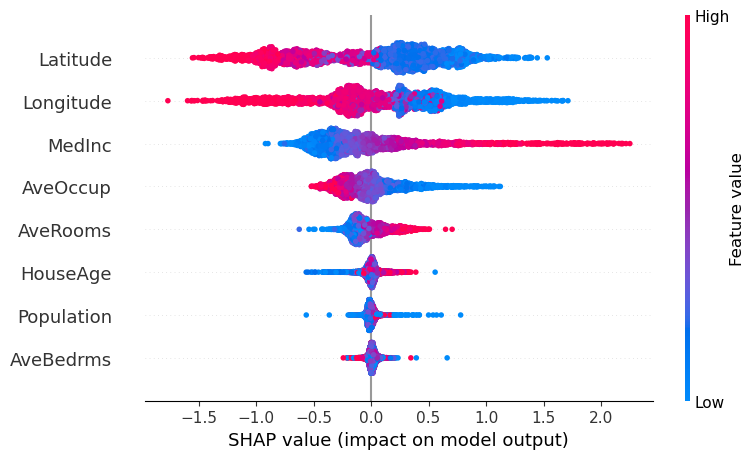

In [5]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

The SHAP summary plot shows that the most important features are Latitude, Longitude, and MedInc. This indicates that both geographical location and socioeconomic factors play a major role in determining housing prices. Geographical variables demonstrate complex effects, while MedInc has a strong positive influence on the predicted value.

## Mean absolute SHAP values

To quantify feature importance numerically, the mean absolute SHAP value is computed for each feature.

In [6]:
importance = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values("importance", ascending=False)

print(feature_importance)

      feature  importance
6    Latitude    0.531429
7   Longitude    0.450650
0      MedInc    0.380113
5    AveOccup    0.194728
2    AveRooms    0.128545
1    HouseAge    0.050199
4  Population    0.027438
3   AveBedrms    0.026573


The mean absolute SHAP values confirm that Latitude and Longitude are the most influential features in the model, followed by MedInc. This means that housing prices depend strongly on location, while income also provides a substantial contribution.

## SHAP interaction values

To analyze pairwise feature interactions, SHAP interaction values are computed. These values show how strongly pairs of features affect the prediction jointly.

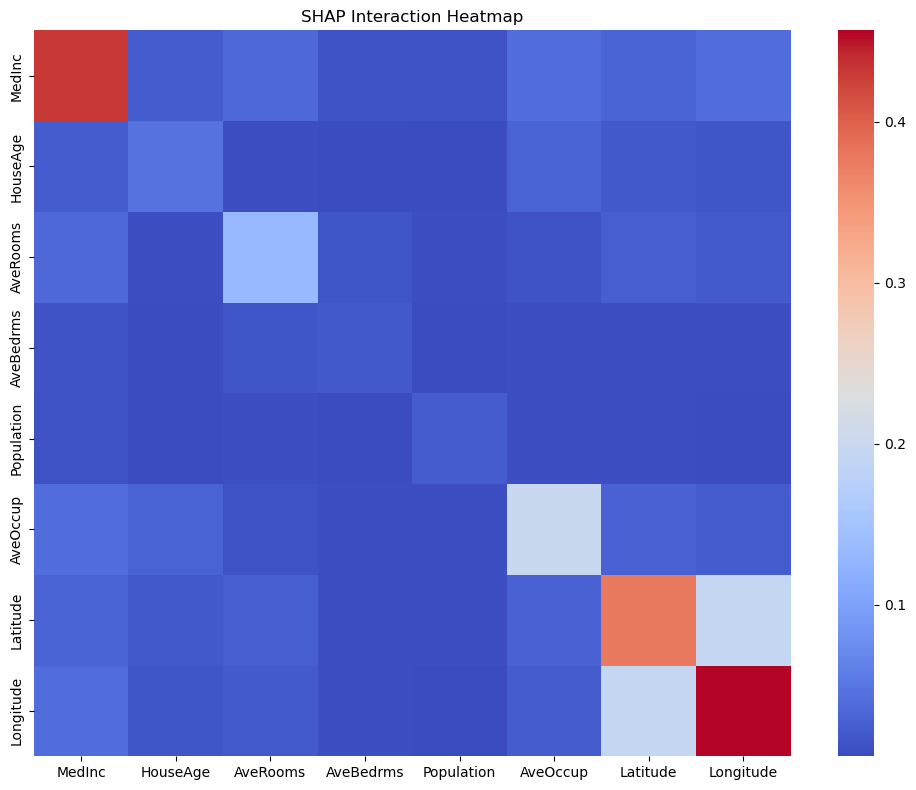

In [7]:
X_small = X_test.sample(min(500, len(X_test)), random_state=42)

interaction_values = explainer.shap_interaction_values(X_small)
interaction_mean = np.abs(interaction_values).mean(axis=0)

interaction_df = pd.DataFrame(
    interaction_mean,
    index=X.columns,
    columns=X.columns
)

plt.figure(figsize=(10, 8))
sns.heatmap(interaction_df, cmap="coolwarm")
plt.title("SHAP Interaction Heatmap")
plt.tight_layout()
plt.show()

The SHAP interaction heatmap shows that the strongest interaction is observed between Latitude and Longitude. This means that geographical location has a strong joint effect on housing prices and should not be considered only through independent one-dimensional contributions. Most other pairs have weaker interaction values, which suggests that they contribute more independently.

## Depth-1 boosting model

Next, a boosting model with trees of depth 1 is trained. Such a model is more interpretable and can be used to construct shape functions for individual features.

In [8]:
stump_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    max_depth=1,
    n_estimators=300,
    learning_rate=0.05,
    n_jobs=-1,
    random_state=42
)

stump_model.fit(X_train, y_train)

stump_pred = stump_model.predict(X_test)
stump_rmse = np.sqrt(mean_squared_error(y_test, stump_pred))
stump_r2 = r2_score(y_test, stump_pred)

print("Depth-1 model RMSE:", stump_rmse)
print("Depth-1 model R2:", stump_r2)

Depth-1 model RMSE: 0.6690546840550814
Depth-1 model R2: 0.6584011726957554


The depth-1 model shows lower predictive performance than the tuned full XGBoost model, which is expected because restricting trees to depth 1 reduces model complexity. However, the main purpose of this model is interpretability rather than maximum predictive accuracy. Such a model allows us to analyze individual feature effects through shape functions.

## Selection of the most important features

The most important features according to SHAP values are selected for shape function analysis.

In [9]:
top_features = feature_importance["feature"].head(3).tolist()
print("Top features:", top_features)

Top features: ['Latitude', 'Longitude', 'MedInc']


## Shape functions for the most important features

Shape functions are constructed for the most important features. Under each graph, the density of the data distribution is shown, following the idea used in Neural Additive Models.

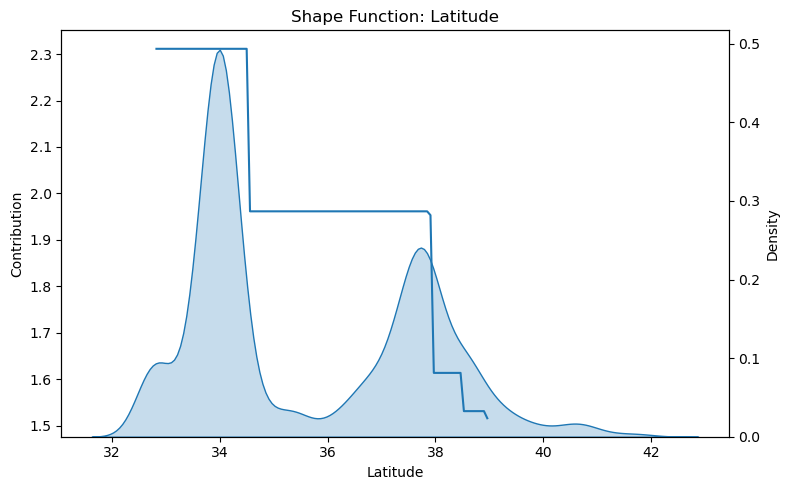

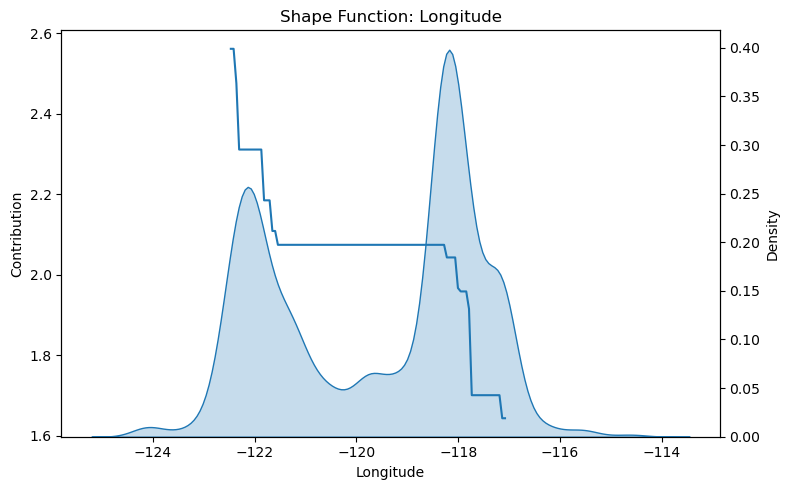

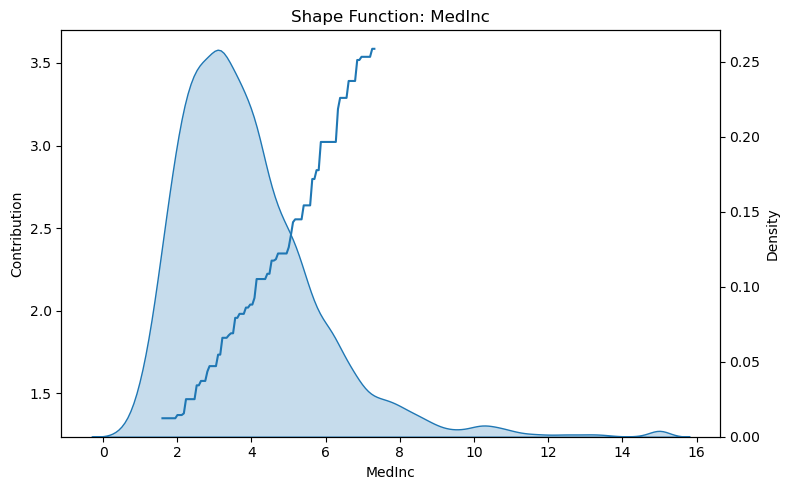

In [10]:
for feature in top_features:
    pd_result = partial_dependence(
        stump_model,
        X_train,
        [feature],
        grid_resolution=100
    )

    if "grid_values" in pd_result:
        grid = pd_result["grid_values"][0]
    else:
        grid = pd_result["values"][0]

    values = pd_result["average"][0]

    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(grid, values)
    ax1.set_xlabel(feature)
    ax1.set_ylabel("Contribution")
    ax1.set_title(f"Shape Function: {feature}")

    ax2 = ax1.twinx()
    sns.kdeplot(x=X_train[feature], ax=ax2, fill=True, alpha=0.25)
    ax2.set_ylabel("Density")

    plt.tight_layout()
    plt.show()

The obtained shape functions demonstrate the individual effect of the most important features on the model prediction.

The shape function for Latitude shows a nonlinear dependence: the largest positive contribution is observed approximately around values 33–35, after which the contribution decreases. This indicates that different latitudinal regions of California affect housing prices differently.

The shape function for Longitude also reveals a nonlinear pattern. The highest contribution is concentrated approximately in the interval -122 to -118, which corresponds to major coastal and metropolitan areas. Moving away from these longitudes leads to a lower contribution to the predicted price.

In contrast, the shape function for MedInc exhibits a mostly monotonic increasing trend. Higher median income corresponds to a larger positive contribution to the housing price prediction, confirming that income is a major socioeconomic determinant of real estate value.

The density curves under the plots show where the training data are concentrated and help interpret in which regions of the feature space the learned dependence is supported by more observations.

## Pairwise shape function for two features

As an additional visualization, a shape function is constructed for a pair of the most important features in the form of a heatmap.

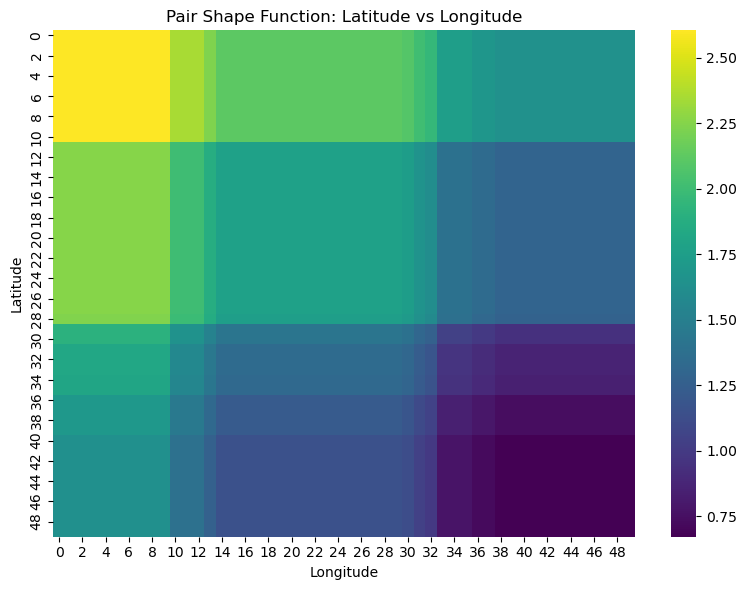

In [11]:
f1 = top_features[0]
f2 = top_features[1]

grid1 = np.linspace(X_train[f1].min(), X_train[f1].max(), 50)
grid2 = np.linspace(X_train[f2].min(), X_train[f2].max(), 50)

heatmap = np.zeros((len(grid1), len(grid2)))
base = X_train.mean(numeric_only=True)

for i, v1 in enumerate(grid1):
    for j, v2 in enumerate(grid2):
        row = base.copy()
        row[f1] = v1
        row[f2] = v2
        row_df = pd.DataFrame([row])[X_train.columns]
        heatmap[i, j] = stump_model.predict(row_df)[0]

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap, cmap="viridis")
plt.title(f"Pair Shape Function: {f1} vs {f2}")
plt.xlabel(f2)
plt.ylabel(f1)
plt.tight_layout()
plt.show()

The pairwise shape function for Latitude and Longitude illustrates their strong joint influence on housing prices. The heatmap reveals clear spatial patterns, where certain combinations of latitude and longitude result in significantly higher predicted prices. This confirms the SHAP interaction analysis, according to which Latitude and Longitude form the strongest interacting pair.

## Triple-feature visualization

For the star task, a 3D visualization is constructed for the three most important features. The predicted value is represented by color.

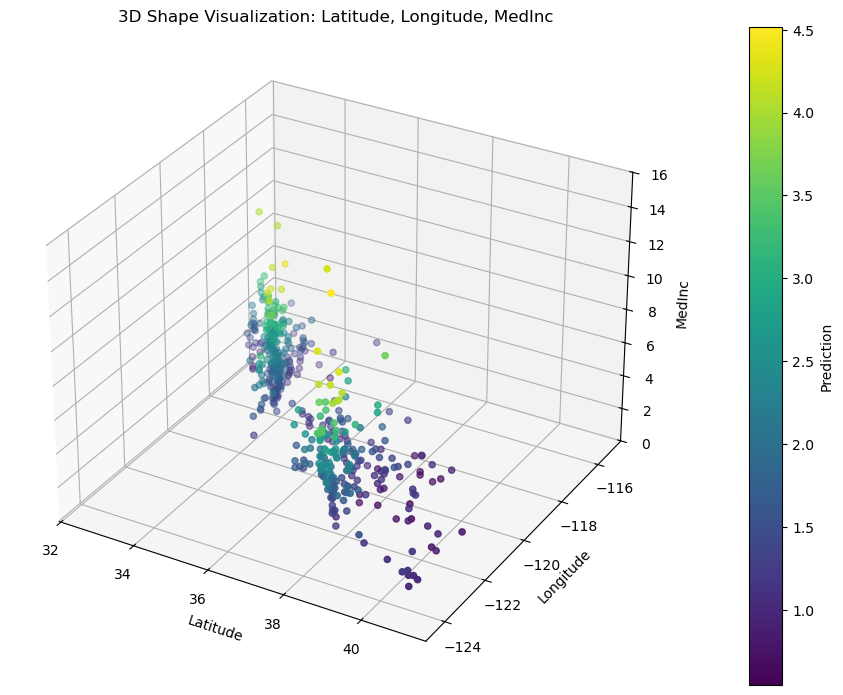

In [13]:
f1, f2, f3 = top_features[:3]

base_row = X_train.mean(numeric_only=True)
sample_base = X_train[[f1, f2, f3]].sample(500, random_state=42).reset_index(drop=True)

full_rows = pd.DataFrame([base_row.values] * len(sample_base), columns=base_row.index)
full_rows[f1] = sample_base[f1].values
full_rows[f2] = sample_base[f2].values
full_rows[f3] = sample_base[f3].values
full_rows = full_rows[X_train.columns]

pred_3d = stump_model.predict(full_rows)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    sample_base[f1],
    sample_base[f2],
    sample_base[f3],
    c=pred_3d
)

ax.set_xlabel(f1)
ax.set_ylabel(f2)
ax.set_zlabel(f3)
ax.set_title(f"3D Shape Visualization: {f1}, {f2}, {f3}")

plt.colorbar(sc, ax=ax, pad=0.1, label="Prediction")
plt.tight_layout()
plt.show()

The 3D visualization of the three most important features shows how the model prediction changes jointly with Latitude, Longitude, and MedInc. The predicted value is represented by color, which makes it possible to observe the combined influence of spatial and socioeconomic factors. This confirms that housing prices depend strongly on both location and income.

## Conclusion

In this work, an XGBoost model was trained on the California Housing dataset and tuned to improve predictive performance. The resulting model achieved strong accuracy on the test set.

SHAP values were then used to analyze feature importance and interaction effects. The results showed that Latitude and Longitude are the most influential features, while MedInc also provides a strong contribution. The SHAP interaction analysis demonstrated that the strongest pairwise interaction occurs between Latitude and Longitude, highlighting the importance of spatial structure.

Next, a depth-1 boosting model was trained to obtain interpretable shape functions. The extracted shape functions showed that geographical variables have complex nonlinear effects, whereas median income has a strong monotonic positive effect on predicted housing prices. Density plots were added below each shape function to show where the data are concentrated.

Finally, additional visualizations were constructed for feature pairs and triples. These plots further confirmed that housing price prediction depends on both spatial and socioeconomic factors and demonstrated the usefulness of explainable boosting and SHAP-based interpretation methods.